# Supplementary figures — mutant simulations

Supporting-information panels for the Nhp6A:DNA metadynamics paper. This notebook
collects the SI material that extends the main-text **Figure 5**, starting with the
three point mutants (**S26D**, **T63D**, **TM**) run with the same soft-wall 2D
well-tempered MetaD protocol as WT holo (`coord_tail_dna` × `d_e2e`, 6 walkers × 300 ns,
all converged on the biased CVs 2026-08-02).

Panels here reuse the Figure-5 plotting conventions (`analysis/scripts/figure5_plot.py`):
the same reliability truncation (`reliable_1d` / `reliable_2d`), colour map, and the
project figure-naming rule. Every code cell is self-contained and re-runnable after a
kernel restart.

**Data provenance** (generated once, then only loaded here):

| panel | table | produced by |
|---|---|---|
| S1 — 2D $F(n_\mathrm{IDR-DNA}, \mathrm{bend})$ | `analysis/<sys>_pmf2d_idrdna_bend.dat` | `dna_bending_wall_compare.py --idrdna-bend-2d` |
| S2 — 1D $F(\mathrm{bend})$ overlay | `analysis/<sys>_pmf_bend_mean_std.dat` | `dna_bending_wall_compare.py` (run_all) |

Both are final-bias reweighted with the same 5-snapshot mean±std ensemble used throughout
the project. `<sys>` ∈ {`DNA_wall2`, `1Nhp6A_wall`, `1S26D_wall`, `1T63D_wall`, `1TM_wall`}.

The 2D tables carry a 6th column, **`n_walkers`** — the number of the 6 walkers that
independently sample each bin (≥50 frames). It drives the ergodicity mask described under
panel S1.

## Panel S1 — 2D PMFs $F(n_\mathrm{IDR-DNA},\ \mathrm{bend})$ for WT and the three mutants

The direct analog of **Figure 5E**, one map per system on identical axes: DNA bend angle
($180-\theta$) on *x*, number of IDR–DNA contacts on *y*, $\Delta F$ colour-coded. Reliability
truncation and colour scale are shared with Figure 5E (`STD_CEIL = 15` kJ/mol,
`MIN_VISITS = 5`, `VMAX = 50` kJ/mol, `RdYlBu_r`).

**Ergodicity mask (`MIN_WALKERS = 3`).** In addition to the Figure-5 sampling/std masks,
a bin is shown only where **at least 3 of the 6 walkers** independently sample it. A region
reached by just one or two walkers is not an equilibrated free-energy estimate even when
densely populated — its reweighted value still drifts in time — and a per-bin std ceiling
does *not* catch this, because two walkers that sit in a bin consistently give it a low
cross-snapshot std. This specifically removes the S26D low-bend / high-contact corner, traced
by a convergence audit to only **2 of 6 walkers**, one entering at 65 ns (see the caveat cell
below). The mask is off by default in `reliable_2d`, so the **main-text Figure 5 panels are
unaffected**; every global minimum here is preserved.

  WT (Nhp6A)  basin: bend   32 deg, n_IDR-DNA 17.2   (reliable bins 1117)
  S26D        basin: bend   21 deg, n_IDR-DNA 10.8   (reliable bins 1299)
  T63D        basin: bend   39 deg, n_IDR-DNA 24.4   (reliable bins 1282)
  TM          basin: bend   17 deg, n_IDR-DNA 16.4   (reliable bins 947)
  saved figures/mutants_pmf2d_idrdna_bend_v2.[pdf|png]  (opaque white -- not a paper panel)


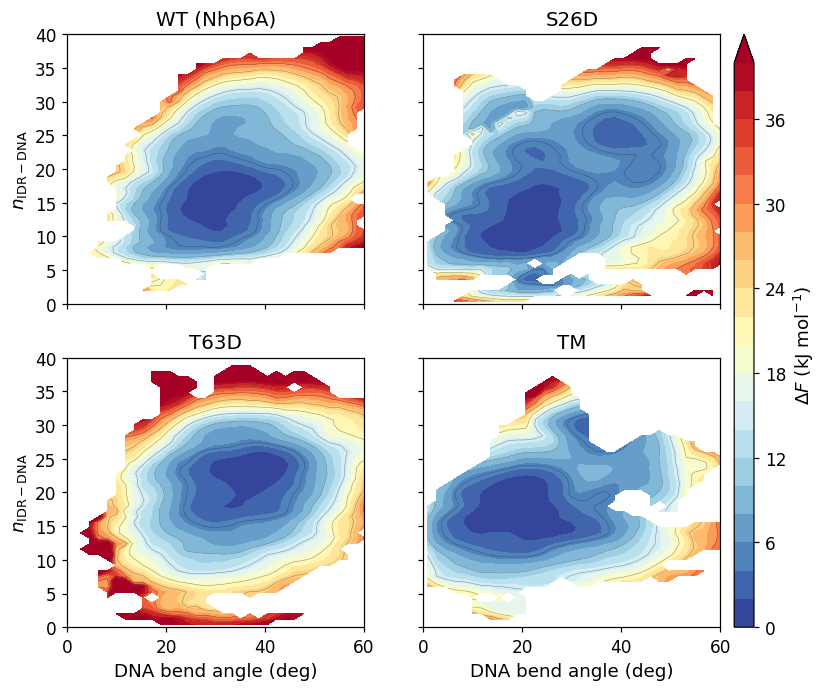

In [8]:
# ─── Panel S1: 2D F(n_IDR-DNA, bend), WT vs the three point mutants ────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — S1 (matched to Figure 5E)
VERSION     = "v2"          # v2: + multi-walker ergodicity mask (min_walkers=3)
XLIM        = (0, 60)       # DNA bend angle (deg)
YLIM        = (0, 40)       # n_IDR-DNA contacts
VMAX        = 40           # kJ/mol colour ceiling
CMAP        = "RdYlBu_r"
STD_CEIL    = 50.0
MIN_VISITS  = 3
MIN_WALKERS = 2            # >=3 of 6 walkers must sample a bin (drops non-ergodic regions)
OUT         = "mutants_pmf2d_idrdna_bend"
# system -> panel title. WT first as the reference.
PANELS = [("1Nhp6A_wall", "WT (Nhp6A)"),
          ("1S26D_wall",  "S26D"),
          ("1T63D_wall",  "T63D"),
          ("1TM_wall",    "TM")]

plt.rcParams.update({"font.size": 13, "axes.labelsize": 12, "xtick.labelsize": 11,
                     "ytick.labelsize": 11, "axes.linewidth": 0.8, "figure.dpi": 110,
                     "axes.grid": False, "pdf.fonttype": 42})

fig, axes = plt.subplots(2, 2, figsize=(8.2, 7.0), sharex=True, sharey=True)
levels = np.linspace(0, VMAX, 21)
im = None
for ax, (name, title) in zip(axes.ravel(), PANELS):
    nc, bend, mean, std, cnt, cov = f5.load2d(f"{name}_pmf2d_idrdna_bend.dat",
                                              data="analysis", with_cov=True)
    F = f5.reliable_2d(mean, std, cnt, STD_CEIL, MIN_VISITS,
                       walker_cov=cov, min_walkers=MIN_WALKERS)   # indexed [nc, bend]
    Fm = np.ma.masked_invalid(F)
    # transposed axes: bend on x, n_IDR-DNA on y -> contourf(X=bend, Y=nc, Z=F)
    im = ax.contourf(bend, nc, Fm, levels=levels, cmap=CMAP, extend="max")
    ax.contour(bend, nc, Fm, levels=np.arange(5, VMAX, 5), colors="k",
               linewidths=0.35, alpha=0.45)
    ax.set_title(title, fontsize=13)
    ax.set_xlim(*XLIM)
    if YLIM:
        ax.set_ylim(*YLIM)
    i, j = np.unravel_index(np.nanargmin(np.where(np.isfinite(F), F, np.inf)), F.shape)
    print(f"  {title:11s} basin: bend {bend[j]:4.0f} deg, n_IDR-DNA {nc[i]:4.1f}"
          f"   (reliable bins {np.isfinite(F).sum()})")

for ax in axes[-1, :]:
    ax.set_xlabel("DNA bend angle (deg)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$n_\mathrm{IDR-DNA}$")

cb = fig.colorbar(im, ax=axes, pad=0.02, fraction=0.046, aspect=30)
cb.set_label(r"$\Delta F$ (kJ mol$^{-1}$)")
f5.savepanel(fig, OUT, VERSION, transparent=False)
plt.show()

### Convergence caveat — the S26D low-bend / high-contact region

The white region at low bend and high $n_\mathrm{IDR-DNA}$ in the S26D panel is **masked on
purpose**, not missing data. A convergence audit of that corner (`bend < 25°`, $n_\mathrm{IDR-DNA} > 25$)
found:

- it is populated by **only 2 of the 6 walkers** (wk0 31 %, wk4 38 %; the other four ≤ 0.5 %);
- **wk4 enters only at 65 ns** (median residence 173 ns), so it accumulates that state in the
  second half of the run — cumulative-time snapshots therefore disagree there by construction;
- the cross-snapshot std **grows** when the snapshot count is doubled (5→10: median 2.2→4.7
  kJ/mol), the signature of genuine time-drift rather than finite-sample noise.

So the apparent ~5–6 kJ/mol "second basin" there is an artifact of **incomplete walker mixing**,
not a resolved state, and the ergodicity mask (`min_walkers = 3`) removes it. S26D's global
minimum (bend ≈ 21°, $n_\mathrm{IDR-DNA}$ ≈ 11) and every other system's basins are unaffected.
Fully resolving that corner would need better walker exchange / longer sampling — a new
simulation, out of scope for this figure.

## Panel S2 — DNA-bending PMF, WT vs mutants vs DNA alone

1D reweighted $F(\mathrm{bend})$ overlay, the mutant extension of **Figure 5D1**: how each
point mutation shifts the preferred DNA bend relative to WT holo and to the free DNA
reference. Same reliability truncation (`STD_CEIL = 15` kJ/mol) and axes as Figure 5D1.
Colours follow the Okabe–Ito / Wong palette used in the wall-system comparison figures.

**Uncertainty caveat.** The bend angle is an *unbiased spectator* (only `coord_tail_dna` and
`d_e2e` are biased), and at 300 ns the six walkers are still segregated in bend — per-walker
median bend spans ≈ 21° (WT), 29° (TM), 33° (S26D), 35° (T63D). The bend ordering below
(DNA 8° < TM 20° < S26D 22° < WT 31° < T63D 38°) is what the reweighted PMFs give, but the
**mutant** minima sit on less-mixed landscapes than the WT/DNA references, so the plotted
time-snapshot ±std bands likely *under*state the true (cross-walker) uncertainty on the
mutant curves. Treat the ordering as robust; treat the exact mutant minima as ± a few degrees.

  DNA alone   minimum at   8.2 deg   (reliable 0.8 – 89.2 deg)
  WT (Nhp6A)  minimum at  30.8 deg   (reliable 0.8 – 78.8 deg)
  S26D        minimum at  21.8 deg   (reliable 0.8 – 87.8 deg)
  T63D        minimum at  38.2 deg   (reliable 3.8 – 83.2 deg)
  TM          minimum at  20.2 deg   (reliable 0.8 – 89.2 deg)
  saved figures/mutants_pmf_bend_vs_wt_dna_v1.[pdf|png]  (opaque white -- not a paper panel)


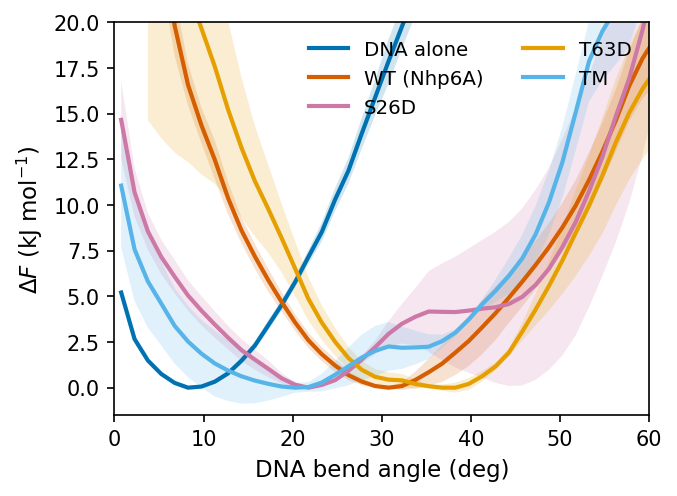

In [ ]:
# ─── Panel S2: 1D F(bend), DNA alone vs WT vs the three mutants ───────────────────
import sys
sys.path.insert(0, "analysis/scripts")
import numpy as np
import matplotlib.pyplot as plt
import figure5_plot as f5

# settings — S2 (matched to Figure 5D1)
VERSION  = "v1"
FIGSIZE  = (4.6, 3.4)
XLIM     = (0, 60)          # degrees
YLIM     = (-1.5, 20)          # kJ/mol
STD_CEIL = 15.0
OUT      = "mutants_pmf_bend_vs_wt_dna"
# system stem in analysis/<sys>_pmf_bend_mean_std.dat -> (label, colour, linestyle)
SYS = [("DNA_wall2",   "DNA alone", "#0072B2", "-"),   # Okabe-Ito blue
       ("1Nhp6A_wall", "WT (Nhp6A)", "#D55E00", "-"),  # vermillion (WT, established)
       ("1S26D_wall",  "S26D",      "#CC79A7", "-"),   # reddish purple
       ("1T63D_wall",  "T63D",      "#E69F00", "-"),   # orange
       ("1TM_wall",    "TM",        "#56B4E9", "-")]   # sky blue

plt.rcParams.update({"font.size": 12, "axes.labelsize": 11, "xtick.labelsize": 10,
                     "ytick.labelsize": 10, "legend.fontsize": 9.5, "axes.linewidth": 0.8,
                     "figure.dpi": 150, "axes.grid": False, "pdf.fonttype": 42})

fig, ax = plt.subplots(figsize=FIGSIZE)
for name, label, color, ls in SYS:
    d = np.loadtxt(f"analysis/{name}_pmf_bend_mean_std.dat")
    x, m, sd = d[:, 0], d[:, 1], d[:, 2]
    ok = f5.reliable_1d(m, sd, STD_CEIL)
    ax.plot(x[ok], m[ok], lw=2, ls=ls, color=color, label=label)
    ax.fill_between(x[ok], (m - sd)[ok], (m + sd)[ok], color=color, alpha=0.18, lw=0)
    print(f"  {label:11s} minimum at {x[ok][np.nanargmin(m[ok])]:5.1f} deg"
          f"   (reliable {x[ok].min():.1f} – {x[ok].max():.1f} deg)")
ax.set_xlabel("DNA bend angle (deg)")
ax.set_ylabel(r"$\Delta F$ (kJ mol$^{-1}$)")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.legend(frameon=False, loc="upper right", ncol=2)
f5.savepanel(fig, OUT, VERSION, transparent=False)
plt.show()